# 🆎 Pruebas A/B: Validación del Sistema de Recomendaciones

Las plataformas digitales buscan constantemente mejorar la experiencia de sus usuarios para aumentar la interacción, la conversión y, en última instancia, los ingresos del negocio. Sin embargo, implementar cambios en el producto sin evidencia puede generar resultados contrarios a los esperados, afectando negativamente el comportamiento de los usuarios.

En este contexto, la empresa desarrolló un nuevo sistema de recomendaciones con el objetivo de facilitar el descubrimiento de productos relevantes y mejorar el recorrido del usuario dentro de la plataforma. No obstante, antes de implementar esta solución a gran escala, era necesario comprobar si el nuevo sistema generaba una mejora real en comparación con la versión existente.

Para responder esta necesidad, se diseñó una prueba A/B que permitió comparar el comportamiento de dos grupos de usuarios: un grupo de control que mantuvo la experiencia actual y un grupo experimental expuesto al nuevo sistema de recomendaciones.

A través del análisis de métricas de conversión y pruebas estadísticas, se evaluó si las diferencias observadas entre ambos grupos eran suficientemente significativas para justificar la implementación definitiva de la nueva funcionalidad.

## Cargar y revisar datos

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Lectura de datasets
marketing = pd.read_csv(r"C:\Users\ricar\OneDrive\Escritorio\TRIPLETEN\Proyectos CV\Proyecto de Recomendaciones + Prueba AB\CSV Sistema de Recomendaciones + Prueba AB\ab_project_marketing_events_us.csv")
new_users = pd.read_csv(r"C:\Users\ricar\OneDrive\Escritorio\TRIPLETEN\Proyectos CV\Proyecto de Recomendaciones + Prueba AB\CSV Sistema de Recomendaciones + Prueba AB\final_ab_new_users_upd_us.csv")
events = pd.read_csv(r"C:\Users\ricar\OneDrive\Escritorio\TRIPLETEN\Proyectos CV\Proyecto de Recomendaciones + Prueba AB\CSV Sistema de Recomendaciones + Prueba AB\final_ab_events_upd_us.csv")
participants = pd.read_csv(r"C:\Users\ricar\OneDrive\Escritorio\TRIPLETEN\Proyectos CV\Proyecto de Recomendaciones + Prueba AB\CSV Sistema de Recomendaciones + Prueba AB\final_ab_participants_upd_us.csv")

In [3]:
# Información y visualización de 'marketing'
marketing.info()
print('==========================================================================================================================')
print(marketing.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   name       14 non-null     str  
 1   regions    14 non-null     str  
 2   start_dt   14 non-null     str  
 3   finish_dt  14 non-null     str  
dtypes: str(4)
memory usage: 580.0 bytes
                               name                   regions    start_dt  \
0          Christmas&New Year Promo             EU, N.America  2020-12-25   
1      St. Valentine's Day Giveaway  EU, CIS, APAC, N.America  2020-02-14   
2            St. Patric's Day Promo             EU, N.America  2020-03-17   
3                      Easter Promo  EU, CIS, APAC, N.America  2020-04-12   
4                 4th of July Promo                 N.America  2020-07-04   
5         Black Friday Ads Campaign  EU, CIS, APAC, N.America  2020-11-26   
6            Chinese New Year Promo                      APAC  2020-01-25   
7  Labor day (May 1st) A

In [4]:
# Información y visualización de 'new_users'
new_users.info()
print('==========================================================================================================================')
print(new_users.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 58703 entries, 0 to 58702
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     58703 non-null  str  
 1   first_date  58703 non-null  str  
 2   region      58703 non-null  str  
 3   device      58703 non-null  str  
dtypes: str(4)
memory usage: 1.8 MB
            user_id  first_date     region   device
0  D72A72121175D8BE  2020-12-07         EU       PC
1  F1C668619DFE6E65  2020-12-07  N.America  Android
2  2E1BF1D4C37EA01F  2020-12-07         EU       PC
3  50734A22C0C63768  2020-12-07         EU   iPhone
4  E1BDDCE0DAFA2679  2020-12-07  N.America   iPhone
5  137119F5A9E69421  2020-12-07  N.America   iPhone
6  62F0C741CC42D0CC  2020-12-07       APAC   iPhone
7  8942E64218C9A1ED  2020-12-07         EU       PC
8  499AFACF904BBAE3  2020-12-07  N.America   iPhone
9  FFCEA1179C253104  2020-12-07         EU  Android


In [5]:
# Información y visualización de 'events'
events.info()
print('==========================================================================================================================')
print(events.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 423761 entries, 0 to 423760
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     423761 non-null  str    
 1   event_dt    423761 non-null  str    
 2   event_name  423761 non-null  str    
 3   details     60314 non-null   float64
dtypes: float64(1), str(3)
memory usage: 12.9 MB
            user_id             event_dt event_name  details
0  E1BDDCE0DAFA2679  2020-12-07 20:22:03   purchase    99.99
1  7B6452F081F49504  2020-12-07 09:22:53   purchase     9.99
2  9CD9F34546DF254C  2020-12-07 12:59:29   purchase     4.99
3  96F27A054B191457  2020-12-07 04:02:40   purchase     4.99
4  1FD7660FDF94CA1F  2020-12-07 10:15:09   purchase     4.99
5  831887FE7F2D6CBA  2020-12-07 06:50:29   purchase     4.99
6  6B2F726BFD5F8220  2020-12-07 11:27:42   purchase     4.99
7  BEB37715AACF53B0  2020-12-07 04:26:15   purchase     4.99
8  B5FA27F582227197  2020-12-07 01:46:37   purchase

In [6]:
# Información y visualización de 'participants'
participants.info()
print('==========================================================================================================================')
print(participants.head(10))

<class 'pandas.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   user_id  14525 non-null  str  
 1   group    14525 non-null  str  
 2   ab_test  14525 non-null  str  
dtypes: str(3)
memory usage: 340.6 KB
            user_id group                  ab_test
0  D1ABA3E2887B6A73     A  recommender_system_test
1  A7A3664BD6242119     A  recommender_system_test
2  DABC14FDDFADD29E     A  recommender_system_test
3  04988C5DF189632E     A  recommender_system_test
4  4FF2998A348C484F     A  recommender_system_test
5  7473E0943673C09E     A  recommender_system_test
6  C46FE336D240A054     A  recommender_system_test
7  92CB588012C10D3D     A  recommender_system_test
8  B3A2485649E4A012     A  recommender_system_test
9  66FC298441D50783     A  recommender_system_test


## Exploración de datos

#### Búsqueda de valores duplicados

In [7]:
# Valores duplicados por Dataset
print('Marketing:', marketing.duplicated().sum())
print('New Users:', new_users.duplicated().sum())
print('Events:', events.duplicated().sum())
print('Participants:', participants.duplicated().sum())

Marketing: 0
New Users: 0
Events: 0
Participants: 0


#### Identificación de Valores Nulos

In [8]:
# Valores faltantes por Dataset
print('====> Marketing')
print(marketing.isna().sum())
print()

print('====> New users')
print(new_users.isna().sum())
print()

print('====> Events')
print(events.isna().sum())
print()

print('====> Participants')
print(participants.isna().sum())

====> Marketing
name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64

====> New users
user_id       0
first_date    0
region        0
device        0
dtype: int64

====> Events
user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

====> Participants
user_id    0
group      0
ab_test    0
dtype: int64


In [9]:
# Identificar el por qué hay tantos valores ausentes en la columna 'details' en el dataset 'Events'
print('Los distintos tipos de Eventos son:')
print(events['event_name'].unique())
print('--------------------------------------------------------------------------------------------------------------------------')
print('Cantidad de detalles por Evento:')
print(events.groupby('event_name')['details'].count())

Los distintos tipos de Eventos son:
<StringArray>
['purchase', 'product_cart', 'product_page', 'login']
Length: 4, dtype: str
--------------------------------------------------------------------------------------------------------------------------
Cantidad de detalles por Evento:
event_name
login               0
product_cart        0
product_page        0
purchase        60314
Name: details, dtype: int64


#### Cambio de Dtype de las fechas -> Datetime

In [10]:
# Cambio de dtype de las columnas con fechas de los distintos dataset
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])
new_users['first_date'] = pd.to_datetime(new_users['first_date'])
events['event_dt'] = pd.to_datetime(events['event_dt'])

print("marketing['start_dt']:", marketing['start_dt'].dtype)
print("marketing['finish_dt']:", marketing['finish_dt'].dtype)
print("new_users['first_date']:", new_users['first_date'].dtype)
print("events['event_dt']:", events['event_dt'].dtype)

marketing['start_dt']: datetime64[us]
marketing['finish_dt']: datetime64[us]
new_users['first_date']: datetime64[us]
events['event_dt']: datetime64[us]


In [11]:
# Revisión de periodo temporal duraderos
print('Fecha mínima y máxima de "Marketing" en ["start_dt"]:')
print('Min:', marketing['start_dt'].min())
print('Max:', marketing['start_dt'].max())
print('==========================================================================================================================')
print('Fecha mínima y máxima de "Marketing" en ["finish_dt"]:')
print('Min:', marketing['finish_dt'].min())
print('Max:', marketing['finish_dt'].max())
print('==========================================================================================================================')

#Revisión de periodo temporal -> Importante
print('Fecha mínima y máxima de "Events":')
print('Min:', events['event_dt'].min())
print('Max:', events['event_dt'].max())
print('==========================================================================================================================')
print('Fecha mínima y máxima de "New Users":')
print('Min:', new_users['first_date'].min())
print('Max:', new_users['first_date'].max())

Fecha mínima y máxima de "Marketing" en ["start_dt"]:
Min: 2020-01-25 00:00:00
Max: 2020-12-30 00:00:00
Fecha mínima y máxima de "Marketing" en ["finish_dt"]:
Min: 2020-02-07 00:00:00
Max: 2021-01-07 00:00:00
Fecha mínima y máxima de "Events":
Min: 2020-12-07 00:00:33
Max: 2020-12-30 23:36:33
Fecha mínima y máxima de "New Users":
Min: 2020-12-07 00:00:00
Max: 2020-12-23 00:00:00


#### Distribución por Región

In [12]:
# Identificar las regiones del dataset 'New Users'
print('Los Nuevos Usuarios son:')
print(new_users['region'].value_counts())

Los Nuevos Usuarios son:
region
EU           43396
N.America     9051
CIS           3130
APAC          3126
Name: count, dtype: int64


### Conclusiones
Durante la exploración inicial de los datos no se encontraron registros duplicados, lo que indica una estructura limpia y consistente. Respecto a los valores faltantes, únicamente la columna details presentó una gran cantidad de valores ausentes. Sin embargo, se comprobó que estos corresponden a eventos donde dicha información no es necesaria, por lo que no representan un problema de calidad. Además, las variables de fecha fueron transformadas correctamente al formato datetime, permitiendo trabajar adecuadamente con períodos temporales.

Finalmente, se observó que los eventos registrados se encuentran dentro del rango esperado del experimento y que la mayor parte de los nuevos usuarios pertenece a la región de la Unión Europea, aspecto relevante ya que la prueba está enfocada específicamente en este grupo.

## Análisis Exploratorio de Datos (EDA)
### Conversión de las diferentes etapas de las visitas de los usuarios

In [13]:
# Contar usuarios únicos por evento
funnel = (
    events.groupby('event_name')['user_id']
    .nunique()
    .sort_values(ascending = False)
)

print(funnel)

event_name
login           58696
product_page    38929
purchase        19568
product_cart    19284
Name: user_id, dtype: int64


In [14]:
# Tranformación a tabla y cálculo de porcentajes --> Entendible
funnel_df = (
    events.groupby('event_name')['user_id']
    .nunique()
    .reset_index()
)
funnel_df.columns=['event','users']

# Ordenar manualmente el embudo
order = ['login', 'product_page', 'product_cart', 'purchase']

funnel_df['event'] = pd.Categorical(
    funnel_df['event'],
    categories = order,
    ordered=True
)
funnel_df=funnel_df.sort_values('event')

# Conversión respecto al paso anterior
funnel_df['conversion_%'] = (funnel_df['users'] / funnel_df['users'].shift(1)*100).round(2)
funnel_df.iloc[0,2]=100

display(funnel_df)

,event,users,conversion_%
0,login,58696,100.00
2,product_page,38929,66.32
1,product_cart,19284,49.54
3,purchase,19568,101.47


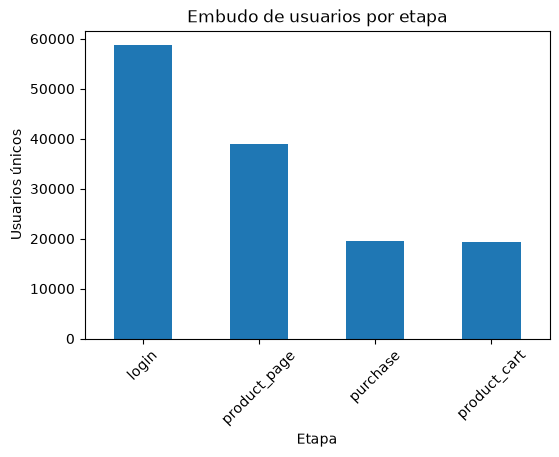

In [15]:
# Embudo de usuarios por etapa
plt.figure(figsize=(6,4))

funnel.plot(kind='bar')
plt.title('Embudo de usuarios por etapa')
plt.xlabel('Etapa')
plt.ylabel('Usuarios únicos')
plt.xticks(rotation=45)
plt.show()

In [19]:
pip install plotly

  Obtaining dependency information for plotly from https://files.pythonhosted.org/packages/f9/14/abe5ce876ab5b66ee3c691bf537fcd43d037aea55d447aacf74630a8f31e/plotly-6.8.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --- ------------------------------------ 1.0/9.9 MB 31.4 MB/s eta 0:00:01
   --------------- ------------------------ 3.9/9.9 MB 35.9 MB/s eta 0:00:01
   ------------------------- -------------- 6.2/9.9 MB 44.5 MB/s eta 0:00:01
   ---------------------------------- ----- 8.5/9.9 MB 45.5 MB/s eta 0:00:01
   ---------------------------------------  9.9/9.9 MB 45.3 MB/s eta 0:00:01
   ---------------------------------------  9.9/9.9 MB 45.3 MB/s eta 0:00:01
   ---------------------------------------  9.9/9.9 MB 45.3 MB/s eta 0:00:01
   ---------------------------------------  9.9/9.9 MB 45.3 MB/s eta 0:00:01
   ---------------------------------------  9.9/9.9 MB 45.3 MB/s eta 0:00:01
   --------------------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import plotly.graph_objects as go

fig = go.Figure(go.Funnel(
    y=[
        'Login',
        'Product Page',
        'Product Cart',
        'Purchase'
    ],
    x=[
        58696,
        38929,
        19284,
        19568
    ],
    textinfo="value+percent previous"
))

fig.update_layout(
    title='Embudo de Conversión de Usuarios',
    width=900,
    height=500
)

fig.show()

In [ ]:
# Verificación si el Flujo es lineal
cart_users = set(events[events['event_name']=='product_cart']['user_id'])
purchase_users = set(events[events['event_name']=='purchase']['user_id'])

purchase_without_cart = purchase_users - cart_users
print('Cantidad de usuarios que no pasaron por ["product_cart"] antes de ["purchase"]:', len(purchase_without_cart))
perc_without_cart = round(len(purchase_without_cart) / len(purchase_users) * 100, 2)

print('Porcentaje de usuarios:', perc_without_cart, '%')

Cantidad de usuarios que no pasaron por ["product_cart"] antes de ["purchase"]: 13169
Porcentaje de usuarios: 67.3 %


#### Comentario
Durante el análisis del embudo se detectó un comportamiento inusual: la conversión entre **product_cart** y **purchase** superó el 100%. Al investigar con mayor detalle se observó que aproximadamente el **67,3%** de los usuarios que realizaron una compra no registraron previamente un evento **product_cart**. Esto sugiere que el flujo de compra no sigue una secuencia completamente lineal y que existen rutas alternativas hacia la compra, como compras directas o eventos intermedios no registrados. Por este motivo, el embudo tradicional debe interpretarse con precaución.

### ¿El número de eventos por usuario está distribuido equitativamente entre las muestras?

In [ ]:
# Unir eventos con participantes (Grupos diferenciados en la columna 'group')
ab_events = participants.merge(
    events,
    on = 'user_id',
    how = 'inner'
)

# Cantidad de eventos por usuario
events_per_user = ab_events.groupby(['group','user_id']).size().reset_index()
events_per_user.columns = ['group', 'user_id','n_events']

display(
    events_per_user.groupby('group')
    ['n_events']
    .describe()
    .round(2)
)

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,7874.0,7.46,4.48,1.0,4.0,6.0,9.0,40.0
B,6205.0,7.11,4.25,1.0,4.0,6.0,9.0,36.0


In [ ]:
# Tasa de conversión por grupo experimental
conversion_by_group = (
    ab_events.groupby('group')['user_id']
    .nunique()
)

purchase_users = (
    ab_events[ab_events['event_name']=='purchase']
    .groupby('group')['user_id']
    .nunique()
)

kpi_conversion = (
    (purchase_users / conversion_by_group) *100
)

print(kpi_conversion.round(2))

group
A    34.06
B    32.36
Name: user_id, dtype: float64


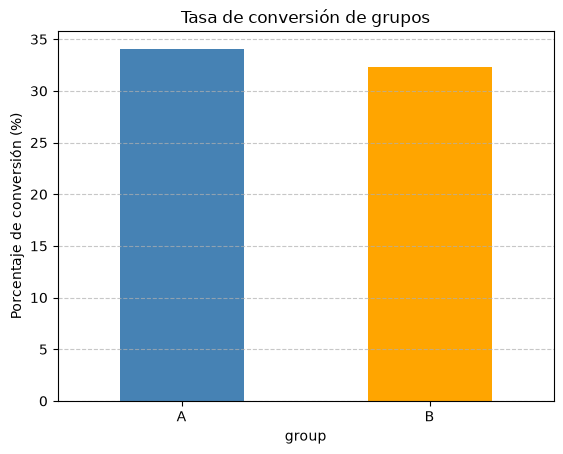

In [ ]:
# Gráfico de Tasa de conversión por grupo experimental
kpi_conversion.plot(
    kind='bar',
    color=['steelblue', 'orange'])
plt.title('Tasa de conversión de grupos')
plt.ylabel('Porcentaje de conversión (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\ricar\AppData\Local\Temp\ipykernel_26032\3963991496.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


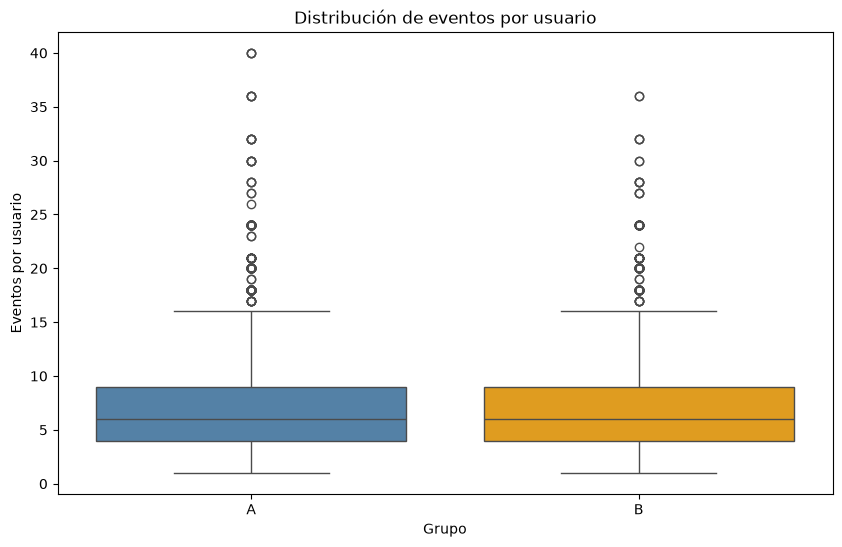

In [ ]:
# Visualización de información sobre eventos por usuario por grupo experimental
plt.figure(figsize=(10,6))
sns.boxplot(
    data=events_per_user,
    x='group',
    y='n_events',
    palette=['steelblue', 'orange']
)
plt.title('Distribución de eventos por usuario')
plt.xlabel('Grupo')
plt.ylabel('Eventos por usuario')
plt.show()

#### Comentario
Al analizar la cantidad de eventos por usuario entre las muestras A y B, se observa una **distribución bastante similar**. Ambos grupos presentan una mediana de 6 eventos por usuario y rangos intercuartílicos prácticamente iguales. Aunque el grupo A muestra una media ligeramente superior (7,46 frente a 7,11), la diferencia es pequeña y no parece indicar un desequilibrio importante entre las muestras. Además, ambos grupos presentan usuarios con actividad inusualmente alta, aunque estos valores atípicos aparecen en los dos grupos de manera similar. En general, la distribución de eventos por usuario puede considerarse relativamente equilibrada.

### ¿Hay usuarios que están presentes en ambas muestras?

In [ ]:
# Número de grupos distintos por usuario
users_in_groups = (participants
    .groupby('user_id')['group']
    .nunique()
)

# Usuarios presentes en más de un grupo
duplicated_users = users_in_groups[users_in_groups > 1]

print('Usuarios en ambas muestras:')
print(len(duplicated_users))

Usuarios en ambas muestras:
441


In [ ]:
# Cálculo porcentual de usuarios duplicados por grupo
print('El porcentaje de usuarios que representan los duplicados en ambos grupos:')
print(round(
        len(duplicated_users) / participants['user_id']
            .nunique()*100, 2
    ),
    '%'
)

El porcentaje de usuarios que representan los duplicados en ambos grupos:
3.23 %


In [ ]:
# Eliminar usuarios presentes en ambos grupos
participants_clean = participants[~participants['user_id']
    .isin(duplicated_users.index)]

events_clean = events[~events['user_id']
    .isin(duplicated_users.index)]

new_users_clean = new_users[~new_users['user_id']
    .isin(duplicated_users.index)]

users_check = (participants_clean
    .groupby('user_id')['group']
    .nunique())

print('Cantidad de usuarios presentes en ambos grupos:')
print(len(users_check[users_check > 1]))

Cantidad de usuarios presentes en ambos grupos:
0


#### Comentario
Se identificaron 441 usuarios presentes en ambas muestras, representando aproximadamente un 3,23% del total. Dado que un mismo usuario no debería participar simultáneamente en los grupos A y B, esta situación puede generar contaminación entre muestras y afectar la validez del experimento. Para mantener la independencia entre grupos y evitar sesgos en el análisis posterior, se decidió eliminar estos usuarios de los conjuntos de datos.

### ¿Cómo se distribuye el número de eventos entre los días?

In [ ]:
# Cantidad de eventos por día
events_by_day = (events_clean
    .groupby(events_clean['event_dt'].dt.date)
    .size()
    .reset_index()
)
events_by_day.columns = ['date', 'events']
display(events_by_day)

,date,events
0,2020-12-07,11283
1,2020-12-08,12479
2,2020-12-09,12043
3,2020-12-10,14004
4,2020-12-11,13795
5,2020-12-12,17588
6,2020-12-13,20931
7,2020-12-14,26015
8,2020-12-15,23331
9,2020-12-16,20725


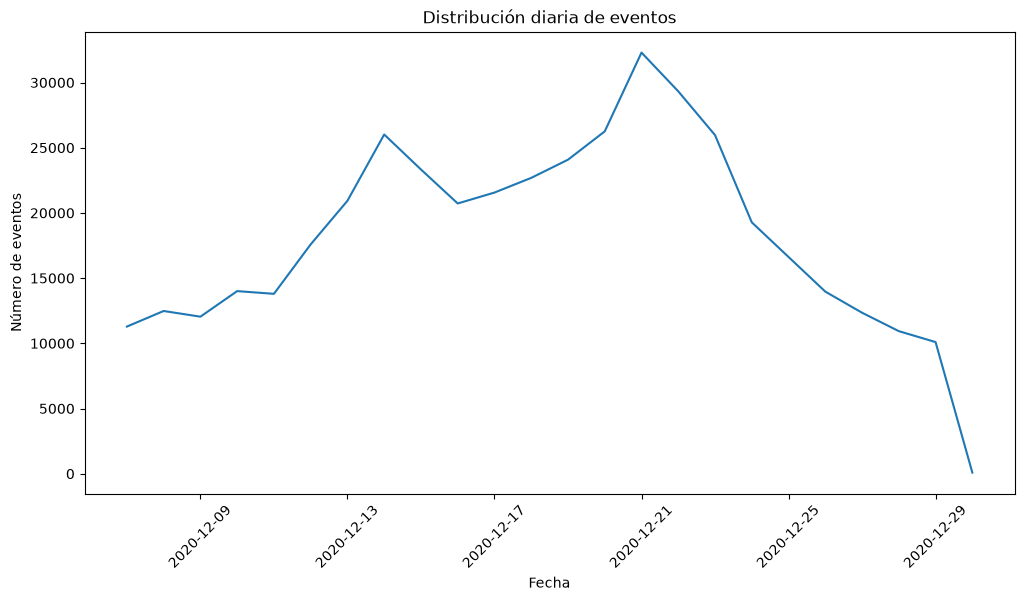

In [ ]:
# Visualización de Distribución diaria de eventos
plt.figure(figsize=(12,6))
sns.lineplot(
    data=events_by_day,
    x='date',
    y='events'
)
plt.xticks(rotation=45)
plt.title('Distribución diaria de eventos')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.show()

#### Comentario
Lo que se aprecia:
* Entre el 7 y el 21 de diciembre los eventos aumentan de forma sostenida.
* El punto más alto ocurre alrededor del 21-12-2020, alcanzando aproximadamente 32.296 eventos.
* Después de esa fecha aparece una disminución progresiva.
* Entre el 23 y 29 de diciembre la caída se vuelve más pronunciada.
* El 30-12-2020 aparece un valor extremadamente bajo (87 eventos), que luce anómalo respecto al resto (incompleto).

La distribución diaria de eventos muestra una tendencia creciente durante la primera parte del experimento, alcanzando su punto máximo alrededor del 21 de diciembre. Posteriormente se observa una disminución progresiva en la actividad, comportamiento que coincide con el cierre del ingreso de nuevos usuarios al estudio. Además, el último día presenta una caída extremadamente pronunciada, lo que podría indicar un registro incompleto o una captura parcial de los datos. En general, la evolución temporal parece consistente con el desarrollo esperado del experimento.

### ¿Hay alguna peculiaridad en los datos que hay que tener en cuenta antes de iniciar la prueba A/B?

1. **Usuarios presentes en ambos grupos**

Se encontraron 441 usuarios en ambas muestras, equivalentes al 3,23% del total. Esto contamina el experimento porque un mismo usuario no debería estar en A y B al mismo tiempo. La medida correcta fue eliminarlos del análisis.

2. **Compras sin evento previo de carrito**

El evento purchase supera a product_cart. Además, detectaste que 13.169 usuarios, es decir, aproximadamente 67,3% de quienes compraron, no registraron un evento previo de carrito. Esto indica que el embudo no es completamente lineal o que puede haber problemas de registro en product_cart.

3. **Fecha límite de nuevos usuarios**

La documentación indica que se dejaron de aceptar nuevos usuarios el 21-12-2020, pero en los datos aparecen usuarios registrados hasta el 23-12-2020. Esto sugiere una diferencia entre la especificación técnica y los datos reales.

4. **Distribución temporal irregular**

Los eventos crecen hasta el 21-12-2020 y luego bajan progresivamente, lo cual tiene sentido por el cierre de nuevos usuarios. Sin embargo, el 30-12-2020 aparece con solo 87 eventos, un valor muy bajo frente a los días anteriores, por lo que podría representar un registro incompleto.

5. **Muestras no perfectamente iguales**

Aunque la distribución de eventos por usuario es similar entre A y B, el tamaño de los grupos no es idéntico: A tiene más usuarios que B. Esto no invalida automáticamente la prueba, pero debe considerarse al interpretar los resultados.

## Evaluación de Resultados de la Prueba A/B
### ¿Qué puedes decir sobre los resultados de la prueba A/B?

In [ ]:
# Usuarios únicos por grupo y evento
ab_events_clean = participants_clean.merge(
    events_clean,
    on='user_id',
    how='inner'
)

conversion = (
    ab_events_clean
    .groupby(['group','event_name'])['user_id']
    .nunique()
    .reset_index()
)

pivot_conversion = conversion.pivot(
    index = 'group',
    columns = 'event_name',
    values = 'user_id'
)

display(pivot_conversion)

event_name,login,product_cart,product_page,purchase
group,,,,
A,7432,2357,4937,2555
B,5763,1911,3715,1881


In [ ]:
# Calculo de conversiones
pivot_conversion['login_to_product'] = (pivot_conversion['product_page'] / pivot_conversion['login'])
pivot_conversion['product_to_cart'] = (pivot_conversion['product_cart'] / pivot_conversion['product_page'])
pivot_conversion['cart_to_purchase'] = (pivot_conversion['purchase'] / pivot_conversion['product_cart'])

display(round(pivot_conversion,2))

event_name,login,product_cart,product_page,purchase,login_to_product,product_to_cart,cart_to_purchase
group,,,,,,,
A,7432,2357,4937,2555,0.66,0.48,1.08
B,5763,1911,3715,1881,0.64,0.51,0.98


#### Comentario
Al comparar las conversiones entre los grupos A y B no se observa una mejora clara y consistente a favor del nuevo sistema de recomendaciones. El grupo B presenta una ligera ventaja en la transición desde la página del producto hacia el carrito, mientras que el grupo A mantiene mejores resultados en la primera etapa del embudo.

Además, la última etapa vuelve a presentar comportamientos atípicos, con conversiones cercanas o superiores al 100%, reforzando la idea de que el flujo de compra no sigue una secuencia completamente lineal, es decir, los eventos *product_cart* y _purchase_ podrían ser paralelos y no estrictamente secuenciales. De manera preliminar, los resultados no parecen respaldar una mejora del 10% esperada en el experimento.

### Evaluación Estadística del Experimento

Tras validar la consistencia de los grupos experimentales y analizar el comportamiento de los usuarios durante el experimento, el siguiente paso consiste en determinar si las diferencias observadas en las tasas de conversión corresponden a un efecto real del nuevo sistema de recomendaciones o si pueden atribuirse a la variabilidad natural de los datos.

Si bien el análisis exploratorio permite identificar tendencias y diferencias aparentes entre grupos, estas observaciones no son suficientes para respaldar una decisión de negocio. Por ello, es necesario aplicar herramientas estadísticas que permitan cuantificar la evidencia disponible y evaluar la significancia de los resultados obtenidos.

Dado que el objetivo es comparar proporciones de conversión entre dos grupos independientes (Control y Experimental), se utilizará una **Prueba Z** para proporciones. Esta metodología permitirá determinar si la implementación del nuevo sistema de recomendaciones genera un impacto estadísticamente significativo sobre el comportamiento de los usuarios.

La pregunta de negocio es: *¿El nuevo sistema de recomendaciones mejora significativamente la conversión de los usuarios en comparación con la experiencia actual?*

Para responder la pregunta, evaluaremos si existe una diferencia significativa entre las tasas de conversión entre dos grupos (A y B):

Hipótesis:
* H0 --> no existe diferencia entre las conversiones de A y B.
* H1 --> existe diferencia entre las conversiones de A y B.

In [ ]:
# Definición de la función Z-test
import math

def z_test(successes1, successes2, trials1, trials2):
    success = np.array([successes1, successes2])
    trials = np.array([trials1, trials2])

    p1 = success[0] / trials[0]
    p2 = success[1] / trials[1]

    p_combined = (successes1 + successes2) / (trials1 + trials2)

    difference = p1 - p2

    se = math.sqrt(p_combined * (1 - p_combined) * (1 / trials1 + 1 / trials2))

    z_value = difference / se

    distr = stats.norm(0,1)
    p_value = (2 *(1 - distr.cdf(abs(z_value)))  )

    return p_value

In [ ]:
# Conversión de Login -> Producto Page
p_value_p1 = z_test(
    pivot_conversion['product_page'].iloc[0],
    pivot_conversion['product_page'].iloc[1],
    pivot_conversion['login'].iloc[0],
    pivot_conversion['login'].iloc[1]
)
print('Conversión de Login -> Product Page')
print('p-value:', p_value_p1.round(4))

alpha = 0.05
if p_value_p1 < alpha:
    print("Rechazar H0: existe diferencia entre las conversiones de A y B.")
else:
    print("No rechazar H0: no existe diferencia entre las conversiones de A y B.")

bonferroni_alpha = 0.05 / 4
if p_value_p1 < alpha:
    print("Con corrección de Bonferroni, Rechazar H0: existe diferencia entre las conversiones de A y B.")
else:
    print("Con corrección de Bonferroni, No rechazar H0: no existe diferencia entre las conversiones de A y B.")

Conversión de Login -> Product Page
p-value: 0.0184
Rechazar H0: existe diferencia entre las conversiones de A y B.
Con corrección de Bonferroni, Rechazar H0: existe diferencia entre las conversiones de A y B.


In [ ]:
# Conversión de Producto Page -> Product Cart
p_value_p2 = z_test(
    pivot_conversion['product_cart'].iloc[0],
    pivot_conversion['product_cart'].iloc[1],
    pivot_conversion['product_page'].iloc[0],
    pivot_conversion['product_page'].iloc[1]
)
print('Conversión de Product Page -> Product Cart')
print('p-value:', p_value_p2.round(4))

alpha = 0.05
if p_value_p2 < alpha:
    print("Rechazar H0: existe diferencia entre las conversiones de A y B.")
else:
    print("No rechazar H0: no existe diferencia entre las conversiones de A y B.")

bonferroni_alpha = 0.05 / 4
if p_value_p2 < alpha:
    print("Con corrección de Bonferroni, Rechazar H0: existe diferencia entre las conversiones de A y B.")
else:
    print("Con corrección de Bonferroni, No rechazar H0: no existe diferencia entre las conversiones de A y B.")

Conversión de Product Page -> Product Cart
p-value: 0.0007
Rechazar H0: existe diferencia entre las conversiones de A y B.
Con corrección de Bonferroni, Rechazar H0: existe diferencia entre las conversiones de A y B.


In [ ]:
# Conversión de Product Page -> Purchase
p_value_p3 = z_test(
    pivot_conversion['purchase'].iloc[0],
    pivot_conversion['purchase'].iloc[1],
    pivot_conversion['product_page'].iloc[0],
    pivot_conversion['product_page'].iloc[1]
)
print('Conversión de Product Page -> Purchase')
print('p-value:', p_value_p3.round(4))

alpha = 0.05
if p_value_p3 < alpha:
    print("Rechazar H0: existe diferencia entre las conversiones de A y B.")
else:
    print("No rechazar H0: no existe diferencia entre las conversiones de A y B.")

bonferroni_alpha = 0.05 / 4
if p_value_p3 < alpha:
    print("Con corrección de Bonferroni, Rechazar H0: existe diferencia entre las conversiones de A y B.")
else:
    print("Con corrección de Bonferroni, No rechazar H0: no existe diferencia entre las conversiones de A y B.")

Conversión de Product Page -> Purchase
p-value: 0.3024
No rechazar H0: no existe diferencia entre las conversiones de A y B.
Con corrección de Bonferroni, No rechazar H0: no existe diferencia entre las conversiones de A y B.


In [ ]:
# Conversión de Login -> Purchase
p_value_p4 = z_test(
    pivot_conversion['purchase'].iloc[0],
    pivot_conversion['purchase'].iloc[1],
    pivot_conversion['login'].iloc[0],
    pivot_conversion['login'].iloc[1]
)
print('Conversión de Login -> Purchase')
print('p-value:', p_value_p4.round(4))

alpha = 0.05
if p_value_p4 < alpha:
    print("Rechazar H0: existe diferencia entre las conversiones de A y B.")
else:
    print("No rechazar H0: no existe diferencia entre las conversiones de A y B.")

bonferroni_alpha = 0.05 / 4
if p_value_p4 < alpha:
    print("Con corrección de Bonferroni, Rechazar H0: existe diferencia entre las conversiones de A y B.")
else:
    print("Con corrección de Bonferroni, No rechazar H0: no existe diferencia entre las conversiones de A y B.")

Conversión de Login -> Purchase
p-value: 0.036
Rechazar H0: existe diferencia entre las conversiones de A y B.
Con corrección de Bonferroni, Rechazar H0: existe diferencia entre las conversiones de A y B.


#### Comentario
Se encontraron diferencias entre A y B en:
* Login → Product Page
* Product Page → Cart
* Login → Purchase

Los resultados de la prueba A/B muestran diferencias estadísticamente significativas en algunas etapas del embudo, indicando que el comportamiento entre los grupos A y B no fue completamente igual. Sin embargo, estas diferencias no favorecen de manera consistente al nuevo sistema de recomendaciones. Aunque el grupo B presentó una ligera mejora en la transición hacia el carrito, el grupo A obtuvo mejores resultados en etapas iniciales y en la conversión final. Además, el incremento esperado del 10% no fue alcanzado. Considerando también las anomalías detectadas previamente en los datos, no existe evidencia suficiente para recomendar implementar el nuevo sistema de recomendaciones.

## Conclusiones de la Etapa EDA y Prueba A/B
Durante la etapa de análisis exploratorio se observó que los datos presentaban una buena calidad general, ya que no se encontraron registros duplicados ni problemas importantes de estructura. Sin embargo, se identificaron algunas particularidades relevantes que debían considerarse antes de iniciar la prueba A/B. Entre ellas:
* Se detectaron usuarios presentes en ambas muestras, los cuales fueron eliminados para evitar contaminación entre grupos.
* Se observó un comportamiento atípico en el embudo de conversión, ya que una gran cantidad de usuarios realizó compras sin registrar previamente un evento de carrito, lo que sugiere que el proceso de compra no sigue una secuencia completamente lineal.
* Se encontraron diferencias entre la documentación y los datos reales respecto a las fechas de incorporación de usuarios, junto con una fuerte caída de eventos al final del período analizado.

En cuanto a la evaluación de la prueba A/B, se encontraron diferencias estadísticamente significativas en algunas etapas del embudo. Sin embargo, estas diferencias no mostraron una mejora consistente a favor del nuevo sistema de recomendaciones. El grupo B presentó una ligera ventaja en ciertas etapas intermedias, mientras que el grupo A mantuvo mejores resultados en conversiones iniciales y finales. Además, el objetivo esperado de aumentar al menos un 10% las conversiones no fue alcanzado.

Finalmente, tras aplicar la corrección de Bonferroni para controlar errores por comparaciones múltiples, las conclusiones se mantuvieron sin cambios, reforzando la consistencia del análisis. En conjunto, los resultados obtenidos no entregan evidencia suficiente para recomendar la implementación del nuevo sistema de recomendaciones.